# NB05 — H2 Test: Genome Compactness (Anchor vs Baseline)

**Hypothesis (RESEARCH_PLAN.md v1.2)**:
- **H1**: Deep-clay Bacillota_B have *smaller* mean genome size and gene count than soil-baseline.
- **H0**: Same.

**Method**: Wilcoxon rank-sum + Cohen's *d* on `genome_size`, `gc_percentage`, and per-genome OG count. CheckM-completeness rescaling: `genome_size_estimated = genome_size / (checkm_completeness / 100)` (compensates for MAG dropout).

**Early signal from NB02**: anchor mean OG count 2,630 vs baseline 2,106 — anchor is *richer*, not poorer. This may be CheckM-rescue effect or genuine accessory-genome richness. NB05 tests properly.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures'); FIG_DIR.mkdir(exist_ok=True)

cohort = pd.read_csv(DATA_DIR / 'cohort_assignments.tsv', sep='\t')
presence = pd.read_parquet(DATA_DIR / 'cohort_og_presence.parquet')
n_ogs = presence.groupby('genome_id').size().reset_index(name='n_ogs')
df = cohort.merge(n_ogs, on='genome_id', how='left')
for c in ['checkm_completeness','genome_size','gc_percentage']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['size_rescaled'] = df['genome_size'] / (df['checkm_completeness'] / 100)
df['n_ogs_rescaled'] = df['n_ogs'] / (df['checkm_completeness'] / 100)
print(df[['cohort_class','genome_size','size_rescaled','gc_percentage','n_ogs','n_ogs_rescaled','checkm_completeness']].groupby(df['cohort_class']).describe(percentiles=[0.5]).round(0))

                 genome_size                                              \
                       count       mean        std        min        50%   
cohort_class                                                               
anchor_deep_clay        10.0  4110038.0  1395395.0  2077804.0  4332544.0   
soil_baseline           62.0  3046125.0   622996.0  1780592.0  2999182.0   

                            size_rescaled                                   \
                        max         count       mean        std        min   
cohort_class                                                                 
anchor_deep_clay  6027195.0          10.0  4323230.0  1410637.0  2189467.0   
soil_baseline     5142254.0          62.0  3233715.0   660164.0  2066330.0   

                  ... n_ogs_rescaled                          \
                  ...            std     min     50%     max   
cohort_class      ...                                          
anchor_deep_clay  ...          632.0

In [2]:
def cohen_d(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    pooled_sd = np.sqrt(((a.var(ddof=1)*(len(a)-1)) + (b.var(ddof=1)*(len(b)-1))) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / pooled_sd if pooled_sd > 0 else np.nan

anchor = df[df['cohort_class']=='anchor_deep_clay']
base   = df[df['cohort_class']=='soil_baseline']

rows = []
for metric in ['genome_size','size_rescaled','gc_percentage','n_ogs','n_ogs_rescaled','checkm_completeness']:
    a = anchor[metric].dropna(); b = base[metric].dropna()
    if len(a) < 3 or len(b) < 3:
        continue
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    rows.append(dict(metric=metric, n_anchor=len(a), n_base=len(b),
                     mean_anchor=a.mean(), mean_base=b.mean(),
                     median_anchor=a.median(), median_base=b.median(),
                     cohens_d=cohen_d(a,b), u=u, p=p))
h2 = pd.DataFrame(rows)
h2['direction'] = h2.apply(lambda r: 'anchor smaller' if r['mean_anchor'] < r['mean_base'] else 'anchor larger', axis=1)
h2.round(3)

,metric,n_anchor,n_base,mean_anchor,mean_base,median_anchor,median_base,cohens_d,u,p,direction
0,genome_size,10,62,4110037.800,3046124.548,4332544.500,2999182.500,1.387,448.0,0.025,anchor larger
1,size_rescaled,10,62,4323230.426,3233715.234,4424795.081,3160603.508,1.367,463.0,0.013,anchor larger
2,gc_percentage,10,62,48.841,47.756,48.383,47.601,0.214,358.0,0.439,anchor larger
3,n_ogs,10,62,2630.100,2105.629,2747.500,2090.500,1.301,451.5,0.022,anchor larger
4,n_ogs_rescaled,10,62,2771.147,2232.788,2800.479,2197.262,1.315,470.0,0.009,anchor larger
5,checkm_completeness,10,62,94.742,94.323,95.385,96.160,0.076,304.0,0.929,anchor larger


/tmp/ipykernel_77979/825067866.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['anchor\n(n=10)','baseline\n(n=62)'], showmeans=True)
/tmp/ipykernel_77979/825067866.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['anchor\n(n=10)','baseline\n(n=62)'], showmeans=True)
/tmp/ipykernel_77979/825067866.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['anchor\n(n=10)','baseline\n(n=62)'], showmeans=True)


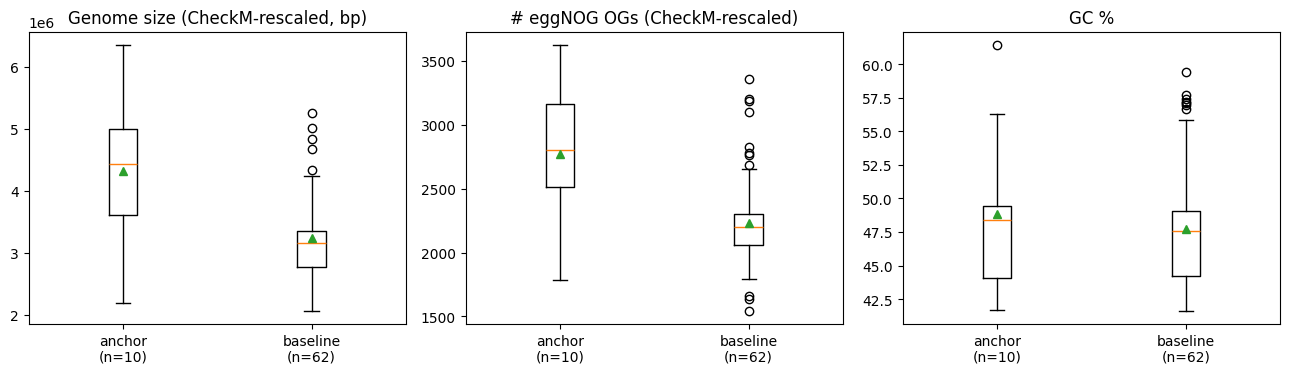

saved: ../figures/h2_compactness.png

verdict on H2: anchor compact-vs-baseline by metric:
  genome_size         anchor larger   d=+1.39  p=0.025  (sig)
  size_rescaled       anchor larger   d=+1.37  p=0.013  (sig)
  gc_percentage       anchor larger   d=+0.21  p=0.439  (n.s.)
  n_ogs               anchor larger   d=+1.30  p=0.022  (sig)
  n_ogs_rescaled      anchor larger   d=+1.32  p=0.009  (sig)
  checkm_completeness  anchor larger   d=+0.08  p=0.929  (n.s.)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric, label in zip(axes,
    ['size_rescaled','n_ogs_rescaled','gc_percentage'],
    ['Genome size (CheckM-rescaled, bp)','# eggNOG OGs (CheckM-rescaled)','GC %']):
    data = [anchor[metric].dropna(), base[metric].dropna()]
    ax.boxplot(data, labels=['anchor\n(n=10)','baseline\n(n=62)'], showmeans=True)
    ax.set_title(label)
plt.tight_layout()
out_fig = FIG_DIR / 'h2_compactness.png'
plt.savefig(out_fig, dpi=140, bbox_inches='tight'); plt.show()
print(f'saved: {out_fig}')
h2.to_csv(DATA_DIR / 'h2_compactness.tsv', sep='\t', index=False)
print(f'\nverdict on H2: anchor compact-vs-baseline by metric:')
for _, row in h2.iterrows():
    sig = 'sig' if row['p'] < 0.05 else 'n.s.'
    print(f'  {row["metric"]:18}  {row["direction"]:14}  d={row["cohens_d"]:+.2f}  p={row["p"]:.3f}  ({sig})')